# Detecção de Fraudes: Visão Geral do Problema

- **Objetivo:** Detectar fraudes em transações de cartão de crédito.
- **Variável alvo (*Class*):** Indica se a transação é legítima ou fraudulenta.
- **Classes:** *0* representa uma transação normal e *1* representa fraude.
- **Desafio:** O conjunto de dados possui um forte desbalanceamento, com uma quantidade extremamente baixa de fraudes em comparação às transações normais.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    roc_auc_score,
    precision_recall_curve
)

from xgboost import XGBClassifier

import shap

In [2]:
url = "https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv"

df = pd.read_csv(url)

## Exploração e Desbalanceamento

In [3]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [5]:
df["Class"].value_counts(normalize=True) * 100

Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64

A classe de fraude representa uma parcela muito pequena das transações. Portanto, a acurácia isoladamente não é adequada para avaliar o modelo.

## Feature Engineering

Criamos variáveis que ajudam o modelo.

In [6]:
df["Amount_log"] = np.log1p(df["Amount"])

In [7]:
X = df.drop("Class", axis=1)
y = df["Class"]

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

print("Treino:", X_train.shape)
print("Teste:", X_test.shape)

Treino: (199364, 31)
Teste: (85443, 31)


In [9]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Regressão Logística

Começaremos com uma Regressão Logística como modelo baseline.

Como existe um forte desbalanceamento entre as classes, utilizaremos
`class_weight="balanced"` para dar maior peso à classe minoritária.

In [10]:
logistic = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

logistic.fit(X_train_scaled, y_train)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to

In [11]:
y_pred_logistic = logistic.predict(X_test_scaled)

y_prob_logistic = logistic.predict_proba(
    X_test_scaled
)[:, 1]

In [12]:
print(
    classification_report(
        y_test,
        y_pred_logistic,
        target_names=["Normal", "Fraude"],
        digits=4
    )
)

              precision    recall  f1-score   support

      Normal     0.9998    0.9783    0.9889     85295
      Fraude     0.0655    0.8784    0.1219       148

    accuracy                         0.9781     85443
   macro avg     0.5326    0.9283    0.5554     85443
weighted avg     0.9982    0.9781    0.9874     85443



## Random Forest

Agora vamos comparar a Regressão Logística com Random Forest.

Também vamos utilizar `class_weight="balanced"` para considerar o
desbalanceamento das classes.

In [13]:
random_forest = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

random_forest.fit(X_train_scaled, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_feat

In [14]:
y_pred_rf = random_forest.predict(X_test_scaled)

y_prob_rf = random_forest.predict_proba(
    X_test_scaled
)[:, 1]

In [15]:
print(
    classification_report(
        y_test,
        y_pred_rf,
        target_names=["Normal", "Fraude"],
        digits=4
    )
)

              precision    recall  f1-score   support

      Normal     0.9996    0.9994    0.9995     85295
      Fraude     0.6824    0.7838    0.7296       148

    accuracy                         0.9990     85443
   macro avg     0.8410    0.8916    0.8645     85443
weighted avg     0.9991    0.9990    0.9990     85443



## XGBoost

O XGBoost será o terceiro modelo utilizado.

Para lidar com o desbalanceamento, vamos utilizar `scale_pos_weight`.

In [16]:
quantidade_normais = (y_train == 0).sum()
quantidade_fraudes = (y_train == 1).sum()

peso_fraude = quantidade_normais / quantidade_fraudes

print("Peso da classe fraude:", peso_fraude)

Peso da classe fraude: 578.546511627907


In [17]:
xgb = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.05,
    scale_pos_weight=peso_fraude,
    eval_metric="logloss",
    random_state=42
)

xgb.fit(X_train_scaled, y_train)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [18]:
y_pred_xgb = xgb.predict(X_test_scaled)

y_prob_xgb = xgb.predict_proba(
    X_test_scaled
)[:, 1]

In [19]:
print(
    classification_report(
        y_test,
        y_pred_xgb,
        target_names=["Normal", "Fraude"],
        digits=4
    )
)

              precision    recall  f1-score   support

      Normal     0.9997    0.9963    0.9980     85295
      Fraude     0.2805    0.8378    0.4203       148

    accuracy                         0.9960     85443
   macro avg     0.6401    0.9171    0.7092     85443
weighted avg     0.9985    0.9960    0.9970     85443



## Comparação dos modelos

Vamos comparar os modelos utilizando as três métricas principais
para a classe de fraude:

- Precision
- Recall
- F1-score

In [20]:
resultados = pd.DataFrame({
    "Modelo": [
        "Regressão Logística",
        "Random Forest",
        "XGBoost"
    ],
    "Precision": [
        precision_score(y_test, y_pred_logistic),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_xgb)
    ],
    "Recall": [
        recall_score(y_test, y_pred_logistic),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_xgb)
    ],
    "F1-score": [
        f1_score(y_test, y_pred_logistic),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_xgb)
    ]
})

resultados

,Modelo,Precision,Recall,F1-score
0,Regressão Logística,0.065491,0.878378,0.121894
1,Random Forest,0.682353,0.783784,0.729560
2,XGBoost,0.280543,0.837838,0.420339


### Análise

Comparando os três modelos, podemos observar diferenças entre
precision, recall e F1-score.

Como o objetivo principal é detectar fraudes, o recall da classe
fraude recebe atenção especial.

Entretanto, a precisão também é importante, pois um número muito
alto de falsos positivos pode fazer com que muitas transações
legítimas sejam classificadas como fraude.

## Curva ROC

A curva ROC mostra a relação entre a taxa de verdadeiros positivos
e a taxa de falsos positivos em diferentes limiares.

In [21]:
fpr_log, tpr_log, _ = roc_curve(
    y_test,
    y_prob_logistic
)

fpr_rf, tpr_rf, _ = roc_curve(
    y_test,
    y_prob_rf
)

fpr_xgb, tpr_xgb, _ = roc_curve(
    y_test,
    y_prob_xgb
)

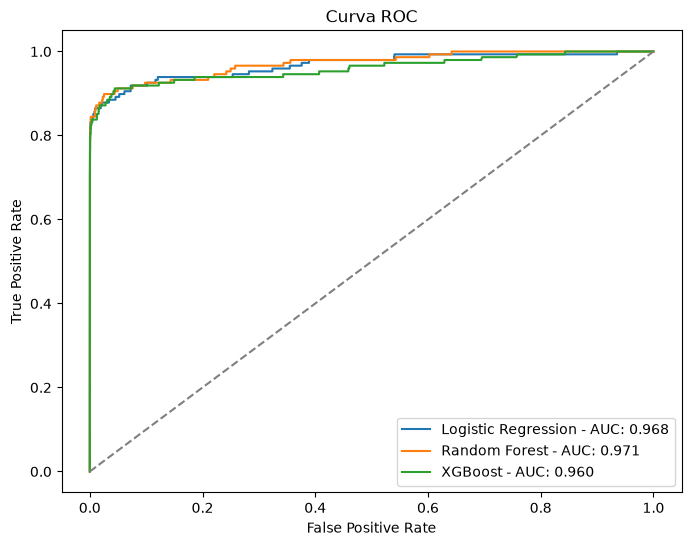

In [22]:
auc_log = roc_auc_score(y_test, y_prob_logistic)
auc_rf = roc_auc_score(y_test, y_prob_rf)
auc_xgb = roc_auc_score(y_test, y_prob_xgb)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_log,
    tpr_log,
    label=f"Logistic Regression - AUC: {auc_log:.3f}"
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest - AUC: {auc_rf:.3f}"
)

plt.plot(
    fpr_xgb,
    tpr_xgb,
    label=f"XGBoost - AUC: {auc_xgb:.3f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    "--",
    color="gray"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC")
plt.legend()

plt.show()

## Curva Precision-Recall

Como a fraude é uma classe muito rara, a relação entre precision
e recall é especialmente importante.

Vamos comparar as curvas dos três modelos.

In [23]:
precision_log, recall_log, _ = precision_recall_curve(
    y_test,
    y_prob_logistic
)

precision_rf, recall_rf, _ = precision_recall_curve(
    y_test,
    y_prob_rf
)

precision_xgb, recall_xgb, _ = precision_recall_curve(
    y_test,
    y_prob_xgb
)

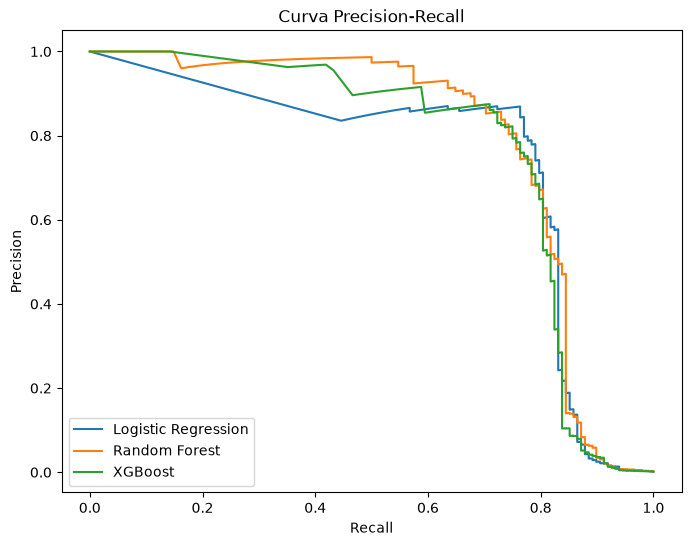

In [24]:
plt.figure(figsize=(8, 6))

plt.plot(
    recall_log,
    precision_log,
    label="Logistic Regression"
)

plt.plot(
    recall_rf,
    precision_rf,
    label="Random Forest"
)

plt.plot(
    recall_xgb,
    precision_xgb,
    label="XGBoost"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Curva Precision-Recall")
plt.legend()

plt.show()

## Ajuste do limiar de decisão

Normalmente, uma probabilidade acima de 0.5 é classificada como
classe positiva.

Porém, podemos alterar esse valor.

Vamos testar alguns limiares e observar como precision, recall e
F1-score mudam.

In [25]:
limiares = [0.2, 0.3, 0.4, 0.5, 0.6]

resultados_limiar = []

for limiar in limiares:

    previsoes = (
        y_prob_xgb >= limiar
    ).astype(int)

    resultados_limiar.append({
        "Limiar": limiar,
        "Precision": precision_score(
            y_test,
            previsoes,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            previsoes,
            zero_division=0
        ),
        "F1-score": f1_score(
            y_test,
            previsoes,
            zero_division=0
        )
    })

tabela_limiares = pd.DataFrame(
    resultados_limiar
)

tabela_limiares

,Limiar,Precision,Recall,F1-score
0,0.2,0.087744,0.851351,0.159091
1,0.3,0.137017,0.837838,0.235518
2,0.4,0.195584,0.837838,0.317136
3,0.5,0.280543,0.837838,0.420339
4,0.6,0.371951,0.824324,0.512605


In [26]:
melhor_linha = tabela_limiares.loc[
    tabela_limiares["F1-score"].idxmax()
]

melhor_limiar = melhor_linha["Limiar"]

print("Limiar escolhido:", melhor_limiar)

Limiar escolhido: 0.6


In [27]:
print("Precision:", melhor_linha["Precision"])
print("Recall:", melhor_linha["Recall"])
print("F1-score:", melhor_linha["F1-score"])

Precision: 0.3719512195121951
Recall: 0.8243243243243243
F1-score: 0.5126050420168067


## Importância das variáveis

O XGBoost permite observar quais variáveis foram mais importantes
para o modelo durante o treinamento.

In [28]:
importancias = pd.DataFrame({
    "Variável": X.columns,
    "Importância": xgb.feature_importances_
})

importancias = importancias.sort_values(
    "Importância",
    ascending=False
)

importancias.head(10)

,Variável,Importância
14,V14,0.505231
4,V4,0.051915
12,V12,0.032629
20,V20,0.032315
10,V10,0.031397
29,Amount,0.026424
8,V8,0.023754
21,V21,0.021889
5,V5,0.020739
13,V13,0.019954


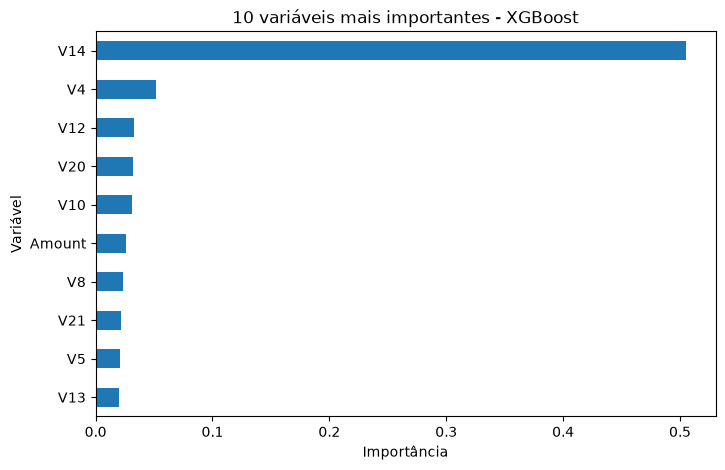

In [29]:
importancias.head(10).sort_values(
    "Importância"
).plot(
    x="Variável",
    y="Importância",
    kind="barh",
    figsize=(8, 5),
    legend=False
)

plt.title("10 variáveis mais importantes - XGBoost")
plt.xlabel("Importância")
plt.show()

## Explicabilidade com SHAP

A importância das variáveis fornece uma visão geral do modelo.

O SHAP permite entender melhor como as variáveis contribuíram para
as previsões do modelo.

In [30]:
explainer = shap.TreeExplainer(xgb)

# Vamos utilizar uma pequena parte do conjunto de teste para manter a visualização mais simples
X_shap = X_test.iloc[:500]

shap_values = explainer.shap_values(X_shap)

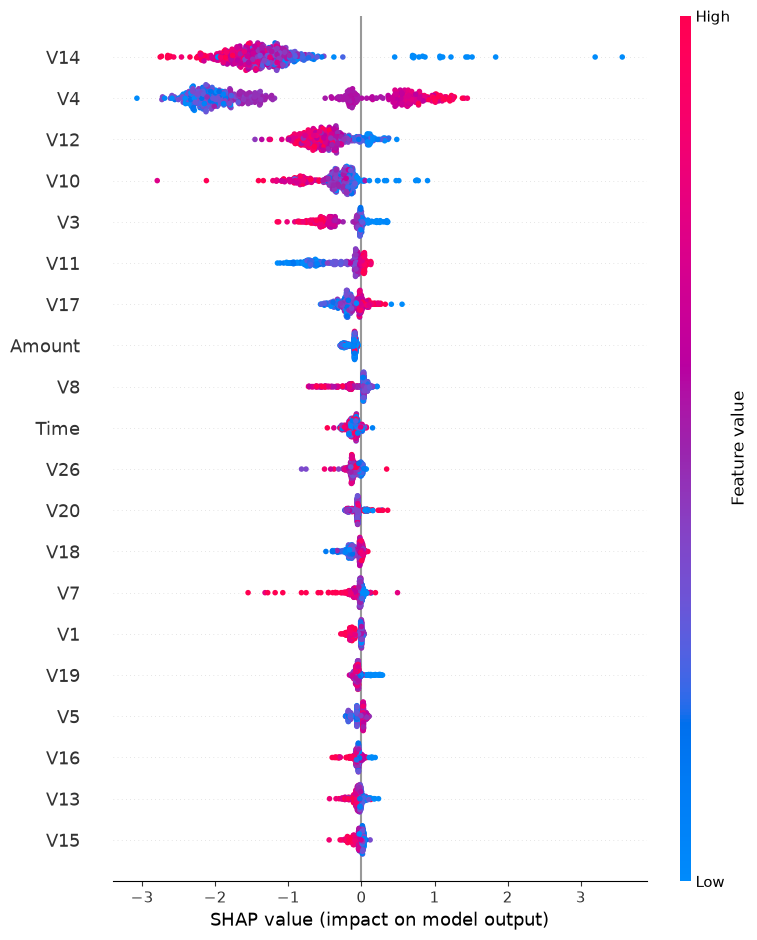

In [31]:
shap.summary_plot(
    shap_values,
    X_shap
)

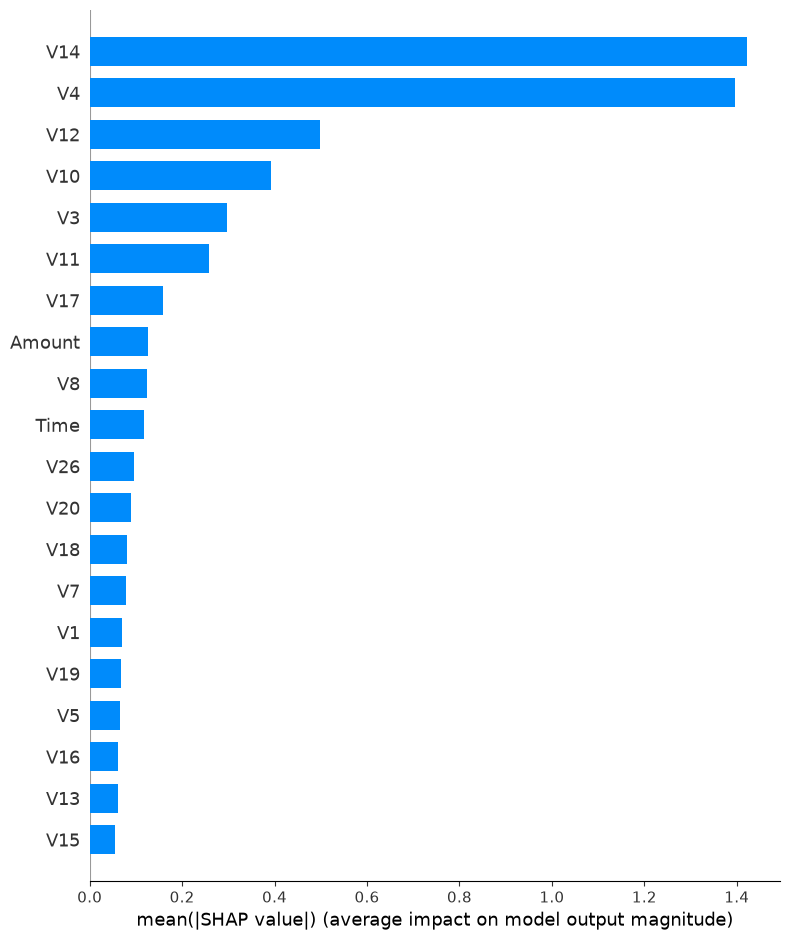

In [32]:
shap.summary_plot(
    shap_values,
    X_shap,
    plot_type="bar"
)

## Explicando uma previsão individual

Agora vamos selecionar uma transação que foi classificada pelo modelo
como fraude e utilizar o SHAP para observar quais variáveis tiveram
maior influência nessa decisão.

In [33]:
# Selecionamos uma transação que está dentro do conjunto utilizado pelo SHAP
# Como X_shap contém as primeiras 500 transações do teste, essa transação certamente estará disponível para a explicação

transacao = X_shap.iloc[[0]]

# Calculamos a probabilidade de fraude para essa transação
probabilidade = xgb.predict_proba(transacao)[0, 1]

print(f"Probabilidade de fraude: {probabilidade:.4f}")

# Aplicamos o limiar que foi escolhido anteriormente no notebook
if probabilidade >= melhor_limiar:
    print("Classificação: Fraude")
else:
    print("Classificação: Normal")

Probabilidade de fraude: 0.0032
Classificação: Normal


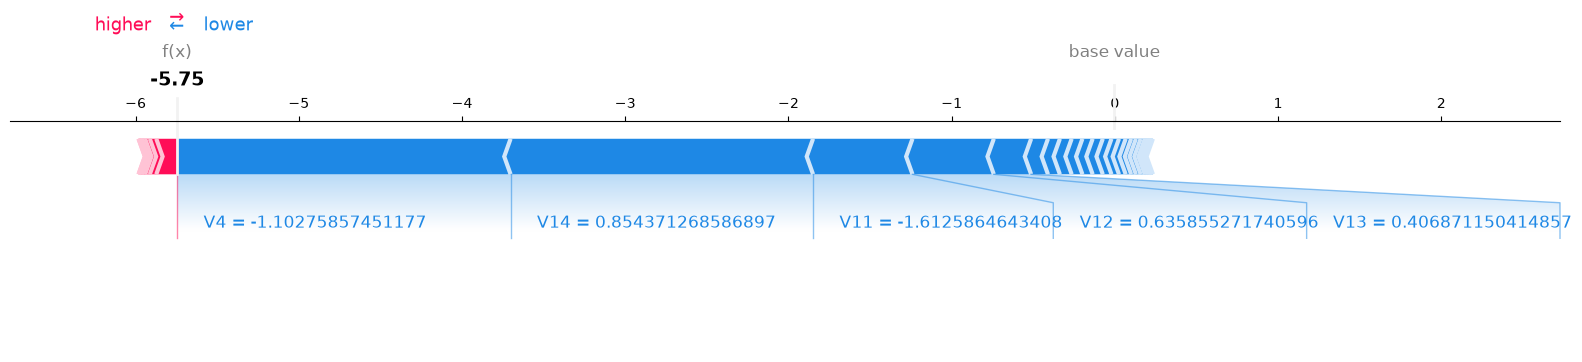

In [34]:
# Calculamos os valores SHAP para a transação selecionada
shap_transacao = explainer.shap_values(transacao)

# Mostramos como as variáveis contribuíram para a previsão
shap.force_plot(
    explainer.expected_value,
    shap_transacao[0],
    transacao.iloc[0],
    matplotlib=True
)

plt.show()

## Conclusão

Neste projeto foi desenvolvido um modelo de detecção de fraudes em
transações de cartão de crédito.

O principal desafio encontrado foi o forte desbalanceamento das classes,
com uma quantidade muito menor de transações fraudulentas.

Por esse motivo, a acurácia não foi utilizada como principal critério
de avaliação. Foram utilizadas principalmente precision, recall e
F1-score para a classe de fraude.

Foram comparados três modelos:

- Regressão Logística
- Random Forest
- XGBoost

Também foi utilizado peso das classes para ajudar os modelos a lidar
com o desbalanceamento.

Além disso, foram analisadas as curvas ROC e Precision-Recall e foram
testados diferentes limiares de decisão no XGBoost.

O limiar escolhido foi baseado no maior F1-score entre os valores
testados.

Por fim, a importância das variáveis e o SHAP foram utilizados para
entender quais características tiveram maior influência nas previsões.

### Resultados

Os modelos foram comparados principalmente pelas métricas de
precision, recall e F1-score da classe fraude.

O modelo Random Forest apresentou recall de 0.7838, precision
de 0.6824 e F1-score de 0.7296.

No teste de diferentes limiares de decisão do XGBoost, o limiar
escolhido foi 0.6, que apresentou precision de 0.37,
recall de 0.82 e F1-score de 0.51.

Na análise de importância das variáveis e SHAP, as variáveis que
mais se destacaram foram V14, V4, V12, V20 e V10.

Esses resultados mostram como o desbalanceamento influencia a
avaliação do modelo e por que recall, precision e F1-score são
mais informativos para este problema do que observar somente a
acurácia.